In [1]:
# ruff: noqa: E402 -- local dev path and plotting style must load before pyplot
import importlib.util
import sys
from pathlib import Path

REPO = Path("/home/hey4/rich_tde")
sys.path.insert(0, str(REPO / "dev"))

import dev  # noqa: F401 -- applies the repository plotting style
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from richio.plots import scalar_map

from dev import SNAPSHOT_TFB

SELECTED_TFB = {"1e4": 1.0, "1e5": 1.0, "1e6": 0.9}
ORBIT_BOX_SCALE = {"1e4": 1.0, "1e5": 1.2, "1e6": 1.2}
ORBIT_RADIUS_SCALE = {"1e4": 0.9, "1e5": 1.0, "1e6": 1.0}
ORBIT_PHASE_OFFSET_DEG = {"1e4": 0.0, "1e5": -13.0, "1e6": -13.0}
RESOLUTION = 768
WORKERS = 8
DPI = 240
DISSIPATION_DECADES = 2.0
TEMPERATURE_TOP_TRIM_DECADES = {"1e4": 2.0, "1e5": 3.0, "1e6": 3.0}
MASK_SMOOTHING_REGION = True
SMOOTHING_RADIUS_RP = 0.6
MASK_COLOR = "black"
XY_WINDOW_RP = (-1.0, 2.0, -1.5, 1.5)
FIGSIZE = (12.0, 5.8)
XY_STREAMLINES = {"color": "white", "density": 1.0, "linewidth": 0.5, "arrowsize": 0.7}
ORBIT_STREAMLINES = {
    "color": "white",
    "density": 0.8,
    "linewidth": 0.55,
    "arrowsize": 0.75,
}
REFERENCE_RADII = ((SMOOTHING_RADIUS_RP, r"$r_0$"), (1.0, r"$r_p$"))
RADIUS_STYLE = {
    "fill": False,
    "edgecolor": "white",
    "linestyle": "--",
    "linewidth": 0.9,
    "zorder": 10,
}
SLICE_LINE_STYLE = {"color": "red", "linewidth": 1.5, "zorder": 12}
OUTPUT_DIR = REPO / "data/processed/PresentationNozzleSlices/xy-phi-z"

FIELDS = (
    ("density", "Density", r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$", "twilight"),
    ("pressure", "Gas pressure", r"$\log_{10}(P/[\mathrm{dyn\,cm^{-2}}])$", "rainbow"),
    (
        "temperature",
        "Gas temperature",
        r"$\log_{10}(T/\mathrm{K})$",
        "inferno",
    ),
    (
        "dissipation",
        "Dissipation",
        r"$\log_{10}(\dot{E}_\mathrm{diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        "viridis",
    ),
)

In [2]:
def load_script(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


xy_batch = load_script(
    "nozzle_zoom_slices", REPO / "works/shock-tde/nozzle-zoom-slices.py"
)
yz_batch = load_script("nozzle_yz_slices", REPO / "works/shock-tde/nozzle-yz-slices.py")

records = {}
for mode, run in enumerate(("1e4", "1e5", "1e6"), start=1):
    requested_tfb = SELECTED_TFB[run]
    snapnum, snapshot_path = SNAPSHOT_TFB(run, requested_tfb)
    snapshot_path = Path(snapshot_path)

    xy_config = xy_batch.mode_settings(mode)
    xy_cache = (
        REPO
        / f"data/processed/NozzleZoomSlices/{run}/grids"
        / f"nozzle_zoom_snap_{snapnum:04d}_{RESOLUTION}.npz"
    )
    if not xy_batch.cache_complete(xy_cache, RESOLUTION):
        print(f"[{run}] gridding XY snapshot {snapnum}", flush=True)
        xy_batch.cache_snapshot(snapshot_path, xy_cache, xy_config, RESOLUTION, WORKERS)

    yz_config = yz_batch.mode_settings(mode)
    box_scale = ORBIT_BOX_SCALE[run]
    radius_scale = ORBIT_RADIUS_SCALE[run]
    phase_offset_deg = ORBIT_PHASE_OFFSET_DEG[run]
    scale_tag = f"{box_scale:g}".replace(".", "p")
    radius_tag = f"{radius_scale:g}".replace(".", "p")
    phase_tag = f"{phase_offset_deg:+g}".replace("+", "p").replace("-", "m")
    orbit_cache = (
        REPO
        / f"data/processed/PresentationNozzleSlices/phi-z/grids/{run}"
        / (
            f"nozzle_phi_z_snap_{snapnum:04d}_{RESOLUTION}_scale_{scale_tag}"
            f"_pericenter_{radius_tag}_phase_{phase_tag}deg.npz"
        )
    )
    if not yz_batch.orbit_cache_complete(orbit_cache, RESOLUTION):
        print(f"[{run}] gridding orbit-following phi-z snapshot {snapnum}", flush=True)
        yz_batch.cache_orbit_snapshot(
            snapshot_path,
            orbit_cache,
            yz_config,
            RESOLUTION,
            WORKERS,
            box_scale=box_scale,
            radius_scale=radius_scale,
            phase_offset_deg=phase_offset_deg,
        )

    with np.load(xy_cache) as data:
        actual_tfb = float(data["time_tfb"])
    records[run] = {
        "snapnum": snapnum,
        "snapshot_path": snapshot_path,
        "xy_cache": xy_cache,
        "orbit_cache": orbit_cache,
        "requested_tfb": requested_tfb,
        "actual_tfb": actual_tfb,
        "box_scale": box_scale,
        "radius_scale": radius_scale,
        "phase_offset_deg": phase_offset_deg,
        "r_p_rsun": yz_config.r_p,
    }
    print(
        f"[{run}] snapshot {snapnum}: t/t_fb={actual_tfb:.3f} "
        f"(requested {requested_tfb:.2f}), orbit box scale={box_scale:g}, "
        f"pericenter scale={radius_scale:g}, phase offset={phase_offset_deg:+g} deg"
    )

[1e4] snapshot 77: t/t_fb=0.999 (requested 1.00), orbit box scale=1, pericenter scale=0.9, phase offset=+0 deg


/tmp/ipykernel_783703/1219854893.py:17: UserWarning: Closest 1e5 snapshot is at 0.606 t_fb, which is 0.394 t_fb from the requested 1.000 t_fb
  snapnum, snapshot_path = SNAPSHOT_TFB(run, requested_tfb)


[1e5] snapshot 161: t/t_fb=0.606 (requested 1.00), orbit box scale=1.2, pericenter scale=1, phase offset=-13 deg


[1e6] snapshot 822: t/t_fb=0.901 (requested 0.90), orbit box scale=1.2, pericenter scale=1, phase offset=-13 deg


In [3]:
def compact_colorbar(fig, ax, image, label):
    cax = inset_axes(
        ax,
        width="100%",
        height="6%",
        loc="lower left",
        bbox_to_anchor=(0.0, 1.085, 1.0, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    bar = fig.colorbar(image, cax=cax, orientation="horizontal")
    bar.set_label(label, fontsize=8, labelpad=1, color="black")
    bar.outline.set_edgecolor("black")
    cax.tick_params(which="both", labelsize=7, length=2, pad=1, colors="black")
    cax.xaxis.set_label_position("top")

1e4: snapshot 77, t/t_fb=0.999, orbit box scale=1, pericenter scale=0.9, phase offset=+0 deg, /data1/projects/pi-rossiem/TDE_data/NewSnellius/R0.47M0.5BH10000beta1S60ComptonHiRes/snap_full_77.h5


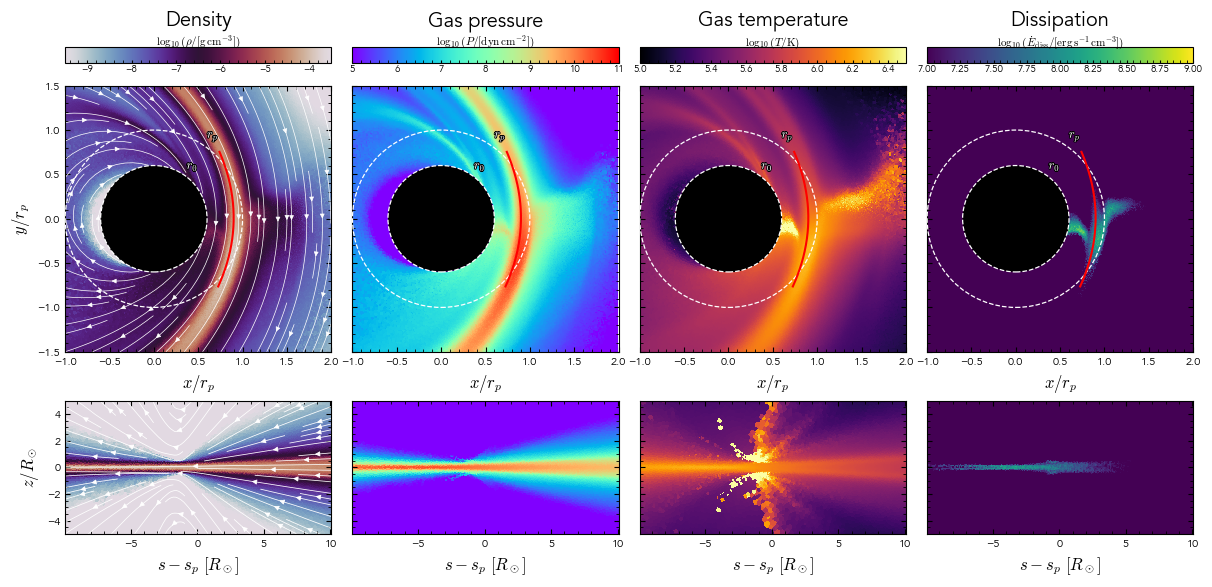

saved /home/hey4/rich_tde/data/processed/PresentationNozzleSlices/xy-phi-z/nozzle_xy_phi_z_1e4_snap_0077.png


1e5: snapshot 161, t/t_fb=0.606, orbit box scale=1.2, pericenter scale=1, phase offset=-13 deg, /data1/projects/pi-rossiem/TDE_data/YujieSnellius/R0.47M0.5BH100000beta1S60n1.5ComptonHiResNewAMR/snap_full_161.h5


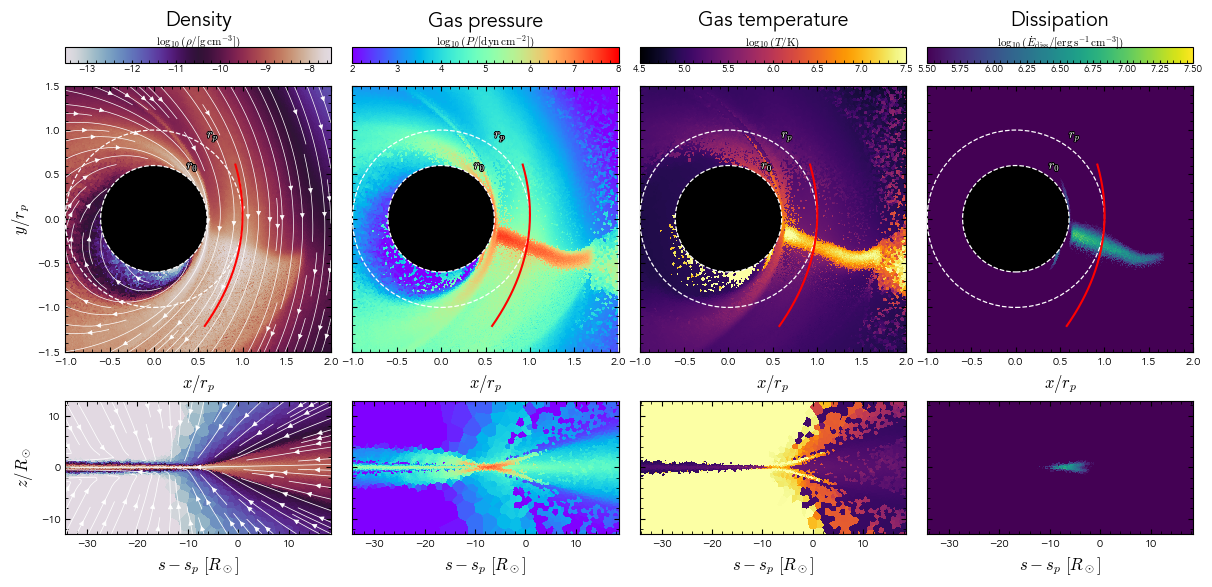

saved /home/hey4/rich_tde/data/processed/PresentationNozzleSlices/xy-phi-z/nozzle_xy_phi_z_1e5_snap_0161.png


1e6: snapshot 822, t/t_fb=0.901, orbit box scale=1.2, pericenter scale=1, phase offset=-13 deg, /data1/projects/pi-rossiem/TDE_data/SS24_diag/TEMPTDE4_new/snap_822.h5


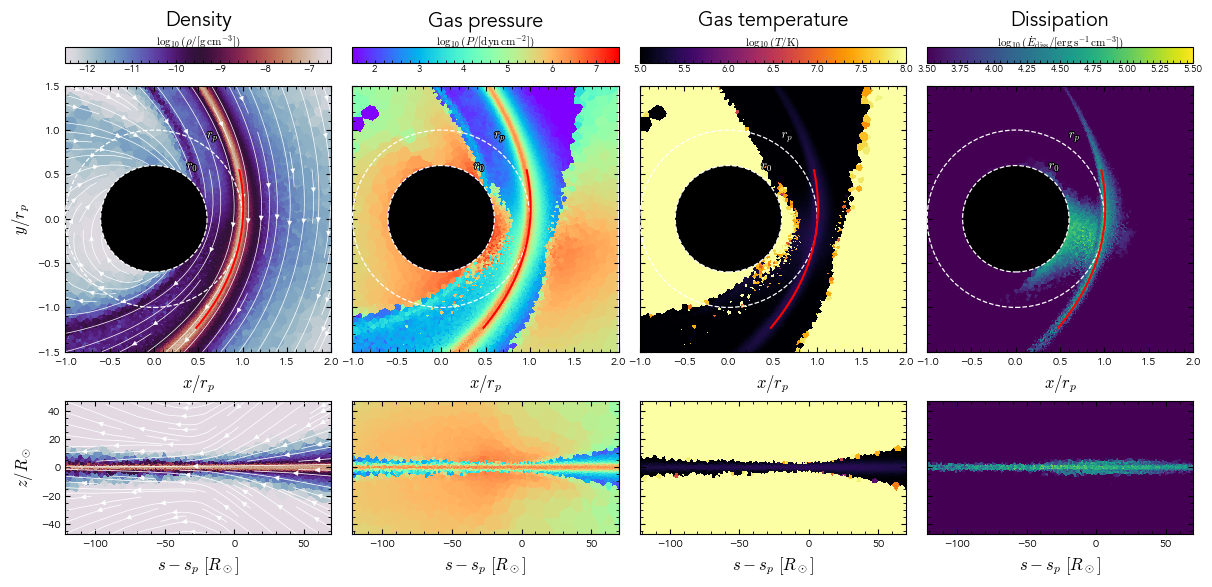

saved /home/hey4/rich_tde/data/processed/PresentationNozzleSlices/xy-phi-z/nozzle_xy_phi_z_1e6_snap_0822.png


In [4]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for run, record in records.items():
    with np.load(record["xy_cache"]) as data:
        xy_x = np.array(data["x_rp"])
        xy_y = np.array(data["y_rp"])
        xy_grids = {name: np.array(data[name]) for name, *_ in FIELDS}
        xy_vx = np.array(data["vx_kms"])
        xy_vy = np.array(data["vy_kms"])
    if MASK_SMOOTHING_REGION:
        smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
        xy_grids = {
            name: np.where(smoothing_mask, np.nan, values)
            for name, values in xy_grids.items()
        }
        xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
        xy_vy = np.where(smoothing_mask, np.nan, xy_vy)
    with np.load(record["orbit_cache"]) as data:
        orbit_phi = np.array(data["phi"])
        orbit_z = np.array(data["z_rsun"])
        orbit_x = np.array(data["orbit_x_rp"])
        orbit_y = np.array(data["orbit_y_rp"])
        orbit_s = np.concatenate(
            ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
        ) * record["r_p_rsun"]
        orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
        orbit_grids = {name: np.array(data[name]) for name, *_ in FIELDS}
        orbit_dphi = np.array(data["dphi_dt"])
        orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
        orbit_dz = np.array(data["dz_rsun_dt"])
    orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
    orbit_ds_stream = np.stack(
        [
            np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
            for column in range(orbit_ds.shape[1])
        ],
        axis=1,
    )
    orbit_dz_stream = np.stack(
        [
            np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
            for column in range(orbit_dz.shape[1])
        ],
        axis=1,
    )

    shared_limits = {}
    for name, *_ in FIELDS:
        finite = np.concatenate(
            [
                xy_grids[name][np.isfinite(xy_grids[name])],
                orbit_grids[name][np.isfinite(orbit_grids[name])],
            ]
        )
        data_min, data_max = float(np.min(finite)), float(np.max(finite))
        if data_max - data_min < 3.0:
            shared_limits[name] = (data_min, data_max)
        else:
            vmax = np.ceil(2.0 * data_max) / 2.0
            shared_limits[name] = (
                max(np.floor(2.0 * data_min) / 2.0, vmax - 6.0),
                vmax,
            )
    dissipation_vmax = shared_limits["dissipation"][1]
    shared_limits["dissipation"] = (
        dissipation_vmax - DISSIPATION_DECADES,
        dissipation_vmax,
    )
    temperature_vmin, temperature_vmax = shared_limits["temperature"]
    shared_limits["temperature"] = (
        temperature_vmin,
        temperature_vmax - TEMPERATURE_TOP_TRIM_DECADES[run],
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=FIGSIZE,
        gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
    )
    for column, (name, title, label, cmap) in enumerate(FIELDS):
        plot_cmap = plt.get_cmap(cmap).copy()
        plot_cmap.set_bad(MASK_COLOR)
        xy_ax = axes[0, column]
        _, xy_image = scalar_map(
            xy_grids[name],
            xy_x,
            xy_y,
            ax=xy_ax,
            cmap=plot_cmap,
            colorbar_label=label,
            log_scale=False,
            vmin=shared_limits[name][0],
            vmax=shared_limits[name][1],
            aspect_equal=False,
            shading="auto",
            rasterized=True,
        )
        xy_image.colorbar.remove()
        compact_colorbar(fig, xy_ax, xy_image, label)
        xy_ax.set_title(title, pad=43)
        xy_ax.set_box_aspect(1.0)
        xy_ax.set_xlim(XY_WINDOW_RP[:2])
        xy_ax.set_ylim(XY_WINDOW_RP[2:])
        if MASK_SMOOTHING_REGION:
            xy_ax.add_patch(
                Circle(
                    (0.0, 0.0),
                    SMOOTHING_RADIUS_RP,
                    facecolor=MASK_COLOR,
                    edgecolor="none",
                    zorder=8,
                )
            )
        xy_ax.plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
        for radius, radius_label in REFERENCE_RADII:
            xy_ax.add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
            angle = np.deg2rad(55.0)
            xy_ax.text(
                radius * np.cos(angle) + 0.025,
                radius * np.sin(angle) + 0.025,
                radius_label,
                color="white",
                fontsize=9,
                ha="left",
                va="bottom",
                path_effects=[
                    path_effects.withStroke(linewidth=1.3, foreground="black")
                ],
                zorder=11,
            )

        orbit_ax = axes[1, column]
        _, orbit_image = scalar_map(
            orbit_grids[name],
            orbit_s,
            orbit_z,
            ax=orbit_ax,
            cmap=plot_cmap,
            colorbar_label=label,
            log_scale=False,
            vmin=shared_limits[name][0],
            vmax=shared_limits[name][1],
            aspect_equal=False,
            shading="auto",
            rasterized=True,
        )
        orbit_image.colorbar.remove()
        orbit_ax.set_box_aspect(0.5)
        orbit_ax.set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
        orbit_ax.set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

    axes[0, 0].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
    axes[1, 0].streamplot(
        orbit_s_stream,
        orbit_z,
        orbit_ds_stream.T,
        orbit_dz_stream.T,
        **ORBIT_STREAMLINES,
    )
    for ax in axes[0]:
        ax.set_xlabel(r"$x/r_p$")
    for ax in axes[1]:
        ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
    axes[0, 0].set_ylabel(r"$y/r_p$")
    axes[1, 0].set_ylabel(r"$z/R_\odot$")
    for ax in axes[:, 1:].flat:
        ax.tick_params(labelleft=False)
    for ax in axes.flat:
        ax.tick_params(labelsize=8)

    fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
    output = OUTPUT_DIR / f"nozzle_xy_phi_z_{run}_snap_{record['snapnum']:04d}.png"
    fig.savefig(output, dpi=DPI, facecolor="white")
    print(
        f"{run}: snapshot {record['snapnum']}, t/t_fb={record['actual_tfb']:.3f}, "
        f"orbit box scale={record['box_scale']:g}, "
        f"pericenter scale={record['radius_scale']:g}, "
        f"phase offset={record['phase_offset_deg']:+g} deg, "
        f"{record['snapshot_path']}"
    )
    display(fig)
    plt.close(fig)
    print(f"saved {output}")